# Part 5

## Hierarchical Conditional CNN

### Importing libraries

In [2]:
import os
import pandas as pd
import numpy as np
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import random
import xml.etree.ElementTree as ET
from PIL import Image
import re
import time
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset
from torchvision import models
from ipywidgets import FileUpload
from io import BytesIO
import torch
import pickle

Earlier, I trained a custom Convolutional Neural Network (CNN) to classify **120 dog breeds** directly. ([Open on GitHub](https://github.com/issaravas/Classification-of-the-breeds-of-dogs/blob/main/breeds_dogs_class.ipynb))
 However, because there were **too many classes** and **only about 150 images per breed**, the model had trouble generalizing - especially when it came to telling apart **breeds that look similar**.

To overcome this, I transitioned from flat classification to a more structured **Hierarchical Conditional Classification** approach.

---

### Why Hierarchical & Conditional?

Rather than predicting 120 breeds directly, the model first predicts a **broader breed group** and then classifies the **specific breed within that group**.

This **hierarchical conditional architecture** allows the model to leverage structural relationships in the dataset, reducing complexity and making better use of limited data. It also mimics the way humans categorize information—first broadly, then specifically—leading to more robust predictions.

I grouped the breeds based on the [American Kennel Club (AKC)](https://en.wikipedia.org/wiki/American_Kennel_Club) classification system, which organizes dog breeds by their historical roles and characteristics (e.g., hunting, herding, companionship).

---
This helps in several ways:
- Reduces complexity at each classification step
- Encourages the model to learn shared features across similar breeds
- Improves accuracy and training efficiency

### Distribution of breeds in groups

In [3]:
df_groups = pd.read_csv("breed_groups.csv")
group_counts = df_groups["group"].value_counts().sort_values(ascending=False)
print(group_counts)

group
Hound           23
Terrier         23
Sporting        18
Working         16
Toy             15
Herding         14
Non-Sporting    11
Name: count, dtype: int64


In [4]:
# breed → group
breed_to_group = dict(zip(df_groups["breed"], df_groups["group"]))

# breed → index
breeds = sorted(df_groups["breed"].unique())
breed_to_idx = {breed: idx for idx, breed in enumerate(breeds)}

# group → index
groups = sorted(df_groups["group"].unique())
group_to_idx = {group: idx for idx, group in enumerate(groups)}

In [4]:
with open("breed_to_idx.pkl", "wb") as f:
    pickle.dump(breed_to_idx, f)

with open("group_to_idx.pkl", "wb") as f:
    pickle.dump(group_to_idx, f)

with open("breed_to_group.pkl", "wb") as f:
    pickle.dump(breed_to_group, f)

In [5]:
from torch.utils.data import Dataset

### Create custom dataset for Hierarchical Conditional CNN

In [6]:
def clean_class_name(class_name):
    return re.sub(r"n\d{8}-", "", class_name)

class HierarchicalDogDataset(Dataset):
    def __init__(self, root_dir, transform, breed_to_group, breed_to_idx, group_to_idx):
        self.samples = []
        self.transform = transform

        for folder in os.listdir(root_dir):
            breed = clean_class_name(folder)
            breed_idx = breed_to_idx[breed]
            group_idx = group_to_idx[breed_to_group[breed]]
            folder_path = os.path.join(root_dir, folder)

            for fname in os.listdir(folder_path):
                if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    path = os.path.join(folder_path, fname)
                    self.samples.append((path, group_idx, breed_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, group_label, breed_label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)
        return image, group_label, breed_label

### Augmentation and Transformation into Tensors

In [7]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(128, scale=(0.95, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.RandomRotation(degrees=15), 
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), 
    transforms.ToTensor(),  
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  
])

In [8]:
transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) 
])

### Data Loaders

In [9]:
base_path = "data/images/resized_dataset"

train_dataset = HierarchicalDogDataset(
    root_dir=os.path.join(base_path, "train"),
    transform=train_transform,
    breed_to_group=breed_to_group,
    breed_to_idx=breed_to_idx,
    group_to_idx=group_to_idx
)

val_dataset = HierarchicalDogDataset(
    root_dir=os.path.join(base_path, "val"),
    transform=transform,
    breed_to_group=breed_to_group,
    breed_to_idx=breed_to_idx,
    group_to_idx=group_to_idx
)

test_dataset = HierarchicalDogDataset(
    root_dir=os.path.join(base_path, "test"),
    transform=transform,
    breed_to_group=breed_to_group,
    breed_to_idx=breed_to_idx,
    group_to_idx=group_to_idx
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


## Building HCNN

The **HCNN_Cndtnl (Hierarchical Conditional Convolutional Neural Network)** is a model specifically designed for **two-stage hierarchical classification**:

1. **Group-level prediction** (e.g., herding, hound, toy, etc.)
2. **Breed-level prediction**, **conditioned on the predicted group**

This conditional design reflects the natural taxonomy of dog breeds and allows the model to first focus on coarse-level distinctions before resolving fine-grained differences within the predicted group.

---

### 1. Shared Convolutional Feature Extractor

The model begins with a **shared convolutional backbone**, which extracts high-level visual features from the input image. It consists of five convolutional blocks with increasing channel depth, batch normalization, ReLU activations, and max pooling. The last layer applies **adaptive average pooling** to produce a fixed-size embedding, regardless of the input resolution.

Key components:
- 5× Conv-BN-ReLU + MaxPool blocks
- AdaptiveAvgPool2d → Flatten → Dropout

This module outputs a **512-dimensional feature vector** shared between both classification heads.

---

### 2. Group Classification Head (Coarse-Level)

This head predicts the **dog group** based on the extracted features. It's a compact fully connected network that outputs class probabilities for each group:

- **Linear(512 → 128)** → ReLU → Dropout(0.3) → **Linear(128 → num_groups)**
- Softmax is applied to produce group probabilities

---

### 3. Breed Classification Head (Fine-Level, Conditional)

The breed-level classifier takes into account the **predicted group**. Instead of using the raw class label, the model uses the **softmax probabilities** from the group head and **concatenates** them with the CNN feature vector. This conditional representation allows the breed classifier to adjust its predictions based on group context.

- **Input**: `[features (512)] + [group_probs (num_groups)]` →  
  Concatenated vector of shape `(512 + num_groups)`
- **Linear(512 + num_groups → 256)** → ReLU → Dropout(0.5) →  
  **Linear(256 → num_breeds)**

This structure ensures that **breed predictions are context-aware**, which is especially useful when some breeds across different groups may look similar but belong to distinct categories.

In [10]:
class HCNN_Cndtnl(nn.Module):
    def __init__(self, num_groups, num_breeds):
        super(HCNN_Cndtnl, self).__init__()

        self.conv_block = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(0.5)

        self.group_head = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_groups)
        )

        self.breed_head = nn.Sequential(
            nn.Linear(512 + num_groups, 256),  
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_breeds)
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = self.flatten(x)
        x = self.dropout(x)

        group_out = self.group_head(x)
        group_probs = F.softmax(group_out, dim=1) 

        x_combined = torch.cat([x, group_probs], dim=1)  

        breed_out = self.breed_head(x_combined)

        return group_out, breed_out

In [11]:
model = HCNN_Cndtnl(num_groups=7, num_breeds=120)

### Train function

In [12]:
def train_model(model, train_loader, val_loader,
                group_loss_fn, breed_loss_fn,
                optimizer, device, epochs=10, alpha=1.0, scheduler=None):

    model.to(device)

    history = {
        "train_group_loss": [],
        "val_group_loss": [],
        "train_breed_loss": [],
        "val_breed_loss": [],
        "train_group_acc": [],
        "val_group_acc": [],
        "train_breed_acc": [],
        "val_breed_acc": []
    }

    for epoch in range(epochs):
        model.train()
        train_group_loss, train_breed_loss = 0.0, 0.0
        group_correct, breed_correct = 0, 0
        total = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        for images, group_labels, breed_labels in loop:
            images = images.to(device)
            group_labels = group_labels.to(device)
            breed_labels = breed_labels.to(device)

            optimizer.zero_grad()
            group_logits, breed_logits = model(images)

            loss_group = group_loss_fn(group_logits, group_labels)
            loss_breed = breed_loss_fn(breed_logits, breed_labels)
            loss = loss_group + alpha * loss_breed
            loss.backward()
            optimizer.step()

            train_group_loss += loss_group.item() * images.size(0)
            train_breed_loss += loss_breed.item() * images.size(0)

            _, group_preds = group_logits.max(1)
            _, breed_preds = breed_logits.max(1)
            group_correct += (group_preds == group_labels).sum().item()
            breed_correct += (breed_preds == breed_labels).sum().item()
            total += images.size(0)

            loop.set_postfix(
                group_acc=100*group_correct/total,
                breed_acc=100*breed_correct/total
            )

        model.eval()
        val_group_loss, val_breed_loss = 0.0, 0.0
        val_group_correct, val_breed_correct = 0, 0
        val_total = 0

        with torch.no_grad():
            for images, group_labels, breed_labels in val_loader:
                images = images.to(device)
                group_labels = group_labels.to(device)
                breed_labels = breed_labels.to(device)

                group_logits, breed_logits = model(images)

                loss_group = group_loss_fn(group_logits, group_labels)
                loss_breed = breed_loss_fn(breed_logits, breed_labels)

                val_group_loss += loss_group.item() * images.size(0)
                val_breed_loss += loss_breed.item() * images.size(0)

                _, group_preds = group_logits.max(1)
                _, breed_preds = breed_logits.max(1)
                val_group_correct += (group_preds == group_labels).sum().item()
                val_breed_correct += (breed_preds == breed_labels).sum().item()
                val_total += images.size(0)

        history["train_group_loss"].append(train_group_loss / total)
        history["train_breed_loss"].append(train_breed_loss / total)
        history["train_group_acc"].append(100 * group_correct / total)
        history["train_breed_acc"].append(100 * breed_correct / total)

        history["val_group_loss"].append(val_group_loss / val_total)
        history["val_breed_loss"].append(val_breed_loss / val_total)
        history["val_group_acc"].append(100 * val_group_correct / val_total)
        history["val_breed_acc"].append(100 * val_breed_correct / val_total)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Group Acc: {history['train_group_acc'][-1]:.2f}% / {history['val_group_acc'][-1]:.2f}% | "
              f"Breed Acc: {history['train_breed_acc'][-1]:.2f}% / {history['val_breed_acc'][-1]:.2f}%")
    
        if scheduler:
            scheduler.step()

    return model, history

### Optimization and Training Setup

The model was trained using the **Adam optimizer** with a learning rate of 0.001 and a weight decay of 1e-5 to prevent overfitting. Learning rate scheduling was applied via **StepLR**, which reduces the learning rate by a factor of 0.5 every 5 epochs.

For loss functions, **cross-entropy loss** was used for both classification tasks:
- One for predicting the **breed group**
- One for predicting the **specific breed**

The total loss was computed as the sum of both losses, optionally weighted by a coefficient `α` (set to 1.0 in this case).


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    group_loss_fn=nn.CrossEntropyLoss(),
    breed_loss_fn=nn.CrossEntropyLoss(),
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    epochs=30,
    alpha=2.0
)

Since my model turned out to be quite heavy, training just **one epoch locally took around 20 minutes**. And because I'm training the model **from scratch**, I expected to need many epochs. So, I decided to use **Kaggle's free GPU**, which provides **30 hours of runtime per week**.  
You can see the training results below.

### The last stage of training:

Epoch [1/20] Group Acc: 69.60% / 79.25% | Breed Acc: 46.47% / 61.62%
                                                                                             
Epoch [2/20] Group Acc: 69.44% / 75.72% | Breed Acc: 46.39% / 59.55%
                                                                                             
Epoch [3/20] Group Acc: 69.03% / 74.77% | Breed Acc: 46.04% / 57.68%
                                                                                             
Epoch [4/20] Group Acc: 69.29% / 63.60% | Breed Acc: 46.10% / 38.84%
                                                                                             
Epoch [5/20] Group Acc: 69.89% / 77.97% | Breed Acc: 46.03% / 59.99%
                                                                                             
Epoch [6/20] Group Acc: 72.51% / 83.68% | Breed Acc: 50.66% / 68.94%
                                                                                             
Epoch [7/20] Group Acc: 74.07% / 81.65% | Breed Acc: 50.71% / 67.22%
                                                                                             
Epoch [8/20] Group Acc: 74.28% / 80.55% | Breed Acc: 51.65% / 65.39%
                                                                                             
Epoch [9/20] Group Acc: 74.76% / 84.69% | Breed Acc: 52.18% / 68.85%
                                                                                              
Epoch [10/20] Group Acc: 74.25% / 83.68% | Breed Acc: 52.78% / 69.40%
                                                                                              
Epoch [11/20] Group Acc: 76.22% / 86.71% | Breed Acc: 55.09% / 72.62%
                                                                                              
Epoch [12/20] Group Acc: 77.27% / 86.87% | Breed Acc: 55.27% / 73.47%
                                                                                              
Epoch [13/20] Group Acc: 76.91% / 84.54% | Breed Acc: 55.24% / 70.41%
                                                                                              
Epoch [14/20] Group Acc: 77.53% / 85.92% | Breed Acc: 55.96% / 72.81%
                                                                                              
Epoch [15/20] Group Acc: 77.57% / 86.60% | Breed Acc: 55.63% / 73.81%
                                                                                              
Epoch [16/20] Group Acc: 77.82% / 87.26% | Breed Acc: 57.47% / 74.51%
                                                                                              
Epoch [17/20] Group Acc: 78.22% / 87.31% | Breed Acc: 57.55% / 75.19%
                                                                                              
Epoch [18/20] Group Acc: 78.64% / 88.02% | Breed Acc: 57.62% / 75.35%
                                                                                              
Epoch [19/20] Group Acc: 79.31% / 87.60% | Breed Acc: 58.68% / 75.33%
                                                                                              
Epoch [20/20] Group Acc: 78.71% / 88.06% | Breed Acc: 58.25% / 75.52%

**How the process went**

I trained the model in multiple stages. Initially, I ran it for **30 epochs**, then saved the checkpoint and resumed training for an additional **20 epochs**. During these stages, I also made adjustments to the training setup, including:

- **Changing the learning rate**
- **Adding stronger data augmentation**
- **Tuning other training parameters**

In total, I **restarted training 9 times**, gradually improving the model. Altogether, the model was trained for **185 epochs**, which was required to reach the results shown.

## Model Evaluation

**load the model**

In [13]:
model = HCNN_Cndtnl(num_groups=7, num_breeds=120)
model.load_state_dict(torch.load("final models/hcnn_9.pth", map_location="cpu"))
model.eval()

C:\Users\User\AppData\Local\Temp\ipykernel_12208\3214498546.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("final models/hcnn_9.pth", m

HCNN_Cndtnl(
  (conv_block): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stat

**load the history data**

In [14]:
with open("final_h_models/history/hcnn_1_h.pkl", "rb") as f:
    hcnn_1_h = pickle.load(f)

with open("final_h_models/history/hcnn_2_h.pkl", "rb") as f:
    hcnn_2_h = pickle.load(f)

with open("final_h_models/history/hcnn_3_h.pkl", "rb") as f:
    hcnn_3_h = pickle.load(f)

with open("final_h_models/history/hcnn_4_h.pkl", "rb") as f:
    hcnn_4_h = pickle.load(f)

with open("final_h_models/history/hcnn_5_h.pkl", "rb") as f:
    hcnn_5_h = pickle.load(f)

with open("final_h_models/history/hcnn_6_h.pkl", "rb") as f:
    hcnn_6_h = pickle.load(f)

with open("final_h_models/history/hcnn_7_h.pkl", "rb") as f:
    hcnn_7_h = pickle.load(f)

with open("final_h_models/history/hcnn_8_h.pkl", "rb") as f:
    hcnn_8_h = pickle.load(f)

with open("final_h_models/history/hcnn_9_h.pkl", "rb") as f:
    hcnn_9_h = pickle.load(f)

In [15]:
all_histories = [hcnn_1_h, hcnn_2_h, hcnn_3_h, hcnn_4_h, hcnn_5_h, hcnn_6_h, hcnn_7_h, hcnn_8_h, hcnn_9_h]

full_history = {
    "train_group_loss": [],
    "val_group_loss": [],
    "train_breed_loss": [],
    "val_breed_loss": [],
    "train_group_acc": [],
    "val_group_acc": [],
    "train_breed_acc": [],
    "val_breed_acc": []
}

for history in all_histories:
    for key in full_history.keys():
        full_history[key] += history[key]

### Let's test the model

In [37]:
import torch.nn.functional as F

In [40]:
def predict_from_path(img_path):
    import torch
    from torchvision import transforms
    from PIL import Image
    import pickle

    with open("final_h_models/breed_to_idx.pkl", "rb") as f:
        breed_to_idx = pickle.load(f)
    with open("final_h_models/group_to_idx.pkl", "rb") as f:
        group_to_idx = pickle.load(f)

    idx_to_breed = {v: k for k, v in breed_to_idx.items()}
    idx_to_group = {v: k for k, v in group_to_idx.items()}

    model = HCNN_Cndtnl(num_groups=len(group_to_idx), num_breeds=len(breed_to_idx))
    model.load_state_dict(torch.load("final_h_models/models/hcnn_9.pth", map_location="cpu"))
    model.eval()

    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])
    image = Image.open(img_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0)

    with torch.no_grad():
        group_logits, breed_logits = model(input_tensor)

    group_probs = torch.softmax(group_logits, dim=1)
    breed_probs = torch.softmax(breed_logits, dim=1)

    group_idx = group_probs.argmax().item()
    breed_idx = breed_probs.argmax().item()

    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Prediction: {idx_to_breed[breed_idx]} ({idx_to_group[group_idx]})")
    plt.show()
    
    print(f"\nImage: {img_path}")
    print(f"Group: {idx_to_group[group_idx]}")
    print(f"Breed: {idx_to_breed[breed_idx]}")

    print("\nTop 5 Most Likely Breeds:")
    top5 = torch.topk(breed_probs, 5)
    for score, idx in zip(top5.values[0], top5.indices[0]):
        print(f"{idx_to_breed[idx.item()]}: {score.item():.2f}")

C:\Users\User\AppData\Local\Temp\ipykernel_12208\554303119.py:16: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



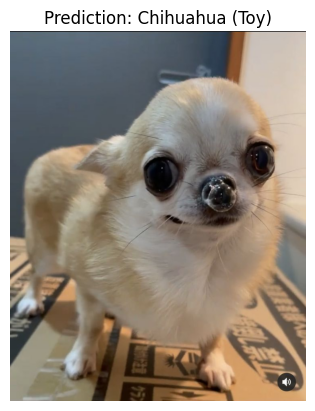


Image: my_images/img_8.jpg
Group: Toy
Breed: Chihuahua

Top 5 Most Likely Breeds:
Chihuahua: 0.40
French_bulldog: 0.26
pug: 0.20
Shih_Tzu: 0.05
Pekinese: 0.03


In [52]:
predict_from_path("my_images/img_8.jpg")

**Note:** \
Thanks to the use of the softmax function in the final layer, we can now retrieve probability scores for each breed!

### Loss/Accuracy plot

In [33]:
def plot_training_results(history):
    epochs = list(range(1, len(history["train_group_loss"]) + 1))

    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=(
            "Train Group Loss", "Validation Group Accuracy",
            "Train Breed Loss", "Validation Breed Accuracy"
        )
    )

    marker_style = dict(size=4)

    fig.add_trace(
        go.Scatter(x=epochs, y=history["train_group_loss"], mode='lines+markers',
                   name='Train Group Loss', marker=marker_style,
                   line=dict(color='#1B56FD')),
        row=1, col=1
    )
    
    fig.add_trace(
        go.Scatter(x=epochs, y=history["val_group_acc"], mode='lines+markers',
                   name='Val Group Accuracy', marker=marker_style,
                   line=dict(color='#FF0080')),
        row=1, col=2
    )

    fig.add_trace(
        go.Scatter(x=epochs, y=history["train_breed_loss"], mode='lines+markers',
                   name='Train Breed Loss', marker=marker_style,
                   line=dict(color='#1B56FD')),
        row=2, col=1
    )

    fig.add_trace(
        go.Scatter(x=epochs, y=history["val_breed_acc"], mode='lines+markers',
                   name='Val Breed Accuracy', marker=marker_style,
                   line=dict(color='#FF0080')),
        row=2, col=2
    )

    fig.update_layout(
        height=900, width=1300, 
        title_text="Hierarchical CNN Training Progress",
        title_x=0.5,
        showlegend=False,
        margin=dict(l=50, r=50, t=70, b=40),
        paper_bgcolor='white',
        plot_bgcolor='white'
    )

    fig.update_xaxes(title_text="Epoch", showgrid=True, gridcolor='lightgray')
    fig.update_yaxes(title_text="Loss", row=1, col=1, showgrid=True, gridcolor='lightgray')
    fig.update_yaxes(title_text="Accuracy (%)", row=1, col=2, showgrid=True, gridcolor='lightgray')
    fig.update_yaxes(title_text="Loss", row=2, col=1, showgrid=True, gridcolor='lightgray')
    fig.update_yaxes(title_text="Accuracy (%)", row=2, col=2, showgrid=True, gridcolor='lightgray')

    fig.show()

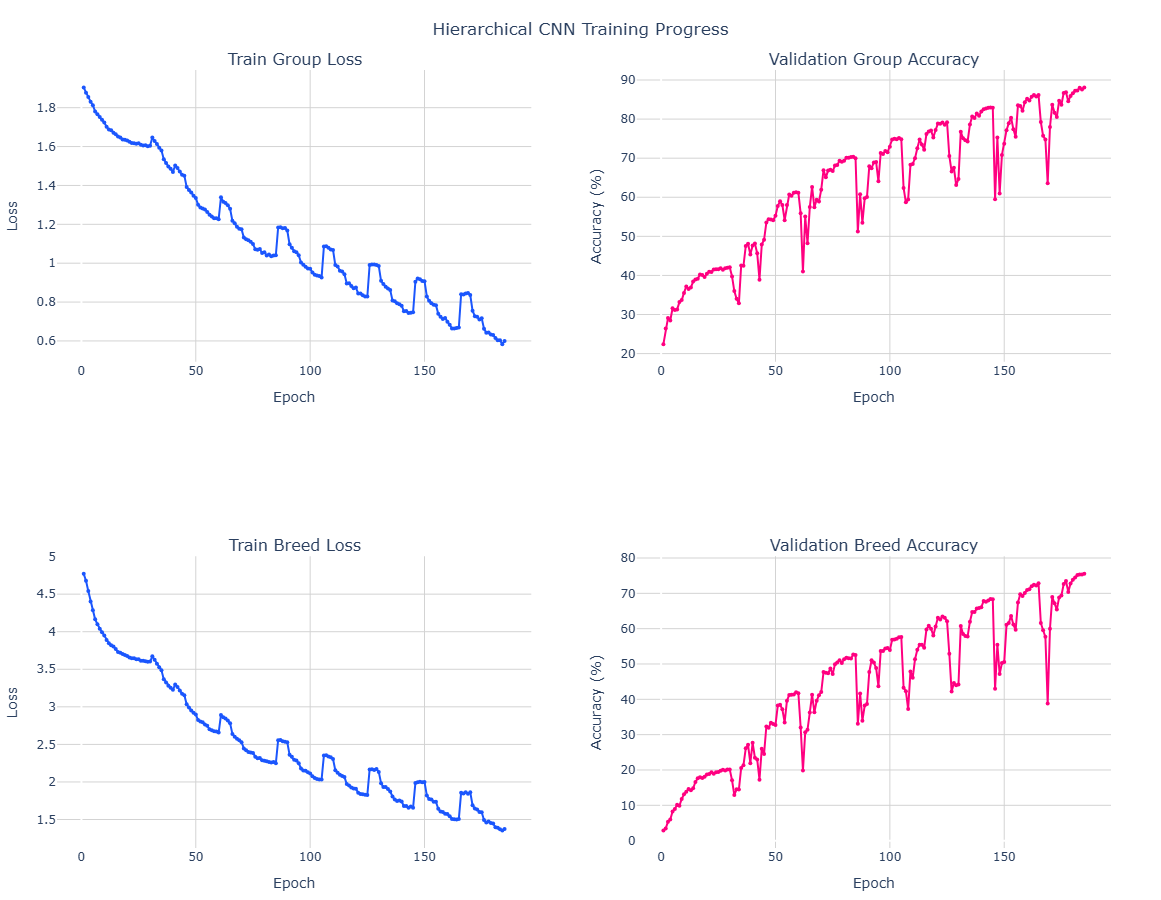

In [34]:
plot_training_results(full_history)

### Confusion matrix 

#### Top-20 Worst F1-Score Breeds

In [57]:
def plot_worst_f1_confusion_matrix(model, dataloader, breed_to_idx, device):
    idx_to_breed = {v: k for k, v in breed_to_idx.items()}
    all_preds, all_labels = [], []

    model.eval()
    with torch.no_grad():
        for images, _, breed_labels in dataloader:
            images = images.to(device)
            breed_labels = breed_labels.to(device)
            _, breed_logits = model(images)
            _, breed_preds = torch.max(breed_logits, 1)
            all_preds.extend(breed_preds.cpu().numpy())
            all_labels.extend(breed_labels.cpu().numpy())

    report = classification_report(all_labels, all_preds, output_dict=True, zero_division=0)
    f1_scores = {int(k): v['f1-score'] for k, v in report.items() if k.isdigit()}

    worst_20 = sorted(f1_scores.items(), key=lambda x: x[1])[:20]
    worst_20_ids = [item[0] for item in worst_20]
    worst_labels = [idx_to_breed[i] for i in worst_20_ids]

    cm = confusion_matrix(all_labels, all_preds)
    cm_worst = cm[np.ix_(worst_20_ids, worst_20_ids)]

    fig, ax = plt.subplots(figsize=(14, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_worst, display_labels=worst_labels)
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=90)
    ax.set_title("Confusion Matrix (20 Worst F1-Score Breeds)")
    plt.grid(False)
    plt.tight_layout()
    plt.show()

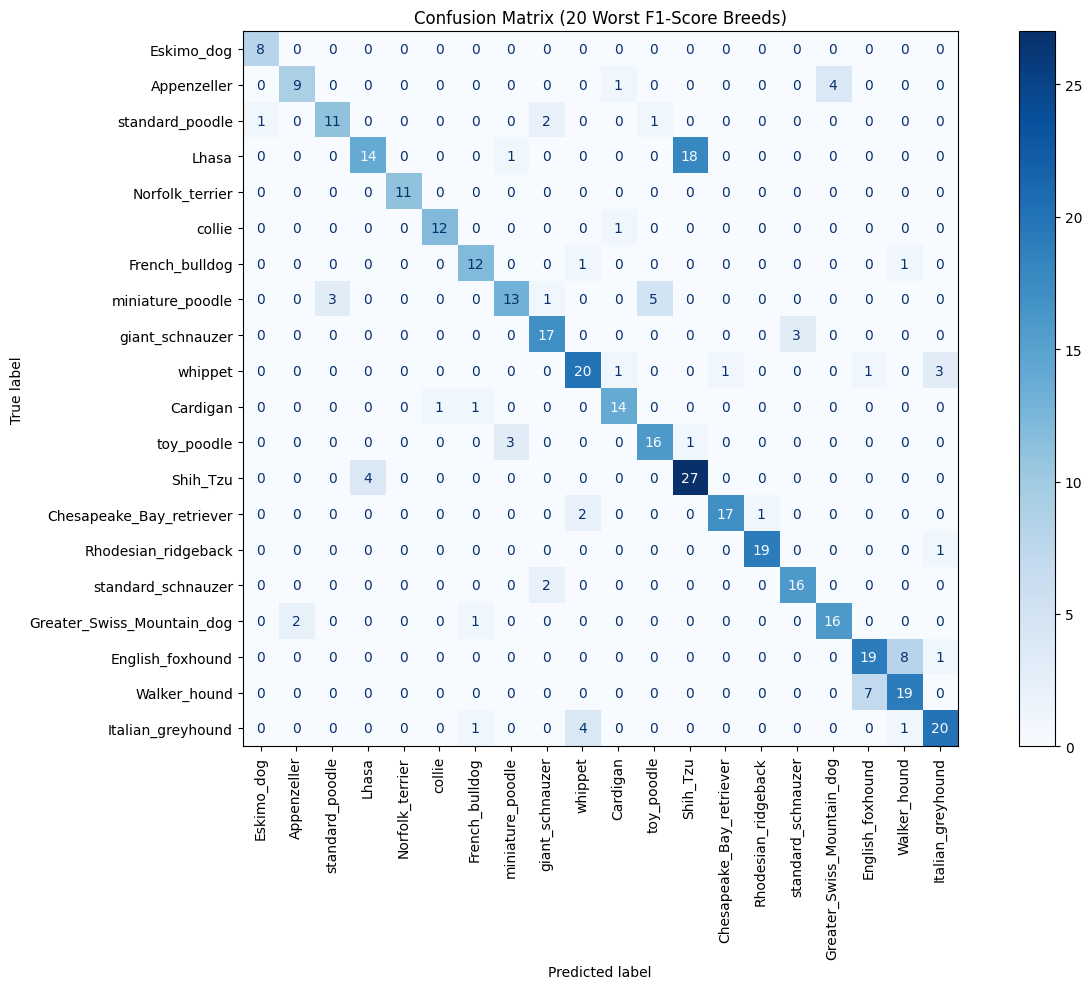

In [58]:
plot_worst_f1_confusion_matrix(model, test_loader, breed_to_idx, device="cpu")

From the confusion matrix of the 20 lowest-performing breeds (by F1-score), the most significant misclassification occurs between **Shih Tzu** and **Lhasa Apso**.  
- Out of 27 actual **Shih Tzu** instances, the model misclassified **18** as **Lhasa Apso**.
  
---

This high rate of confusion is not surprising. Both breeds share very similar physical traits — small size, long flowing coats, short snouts, and similar coloration patterns — making them visually hard to distinguish, even for humans.

Example comparison provided below.

## Shih Tzu
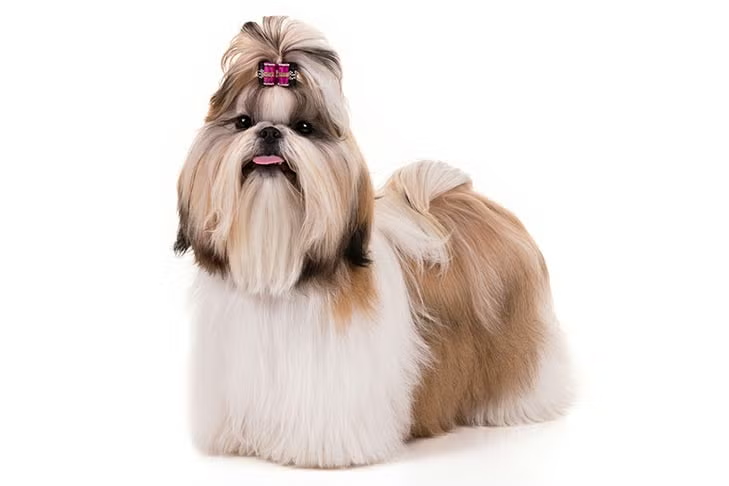

## Lhasa
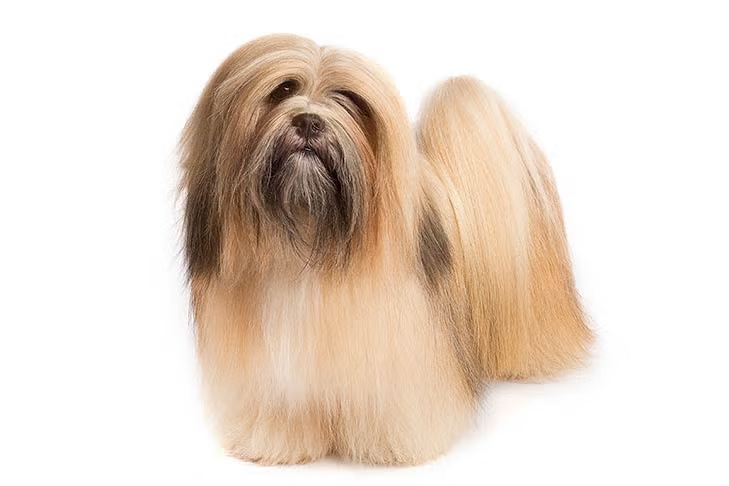

#### Breeds Groups (Confusion matrix)

In [62]:
def plot_group_confusion_matrices(model, dataloader, group_to_idx, device="cpu"):
    idx_to_group = {v: k for k, v in group_to_idx.items()}
    all_preds = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for images, group_labels, _ in dataloader:
            images = images.to(device)
            group_labels = group_labels.to(device)

            group_logits, _ = model(images)
            _, group_preds = torch.max(group_logits, 1)

            all_preds.extend(group_preds.cpu().numpy())
            all_labels.extend(group_labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    group_labels = [idx_to_group[i] for i in range(len(group_to_idx))]

    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=group_labels)
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
    ax.set_title("Confusion Matrix (Breed Groups)")
    plt.grid(False)
    plt.tight_layout()
    plt.show()

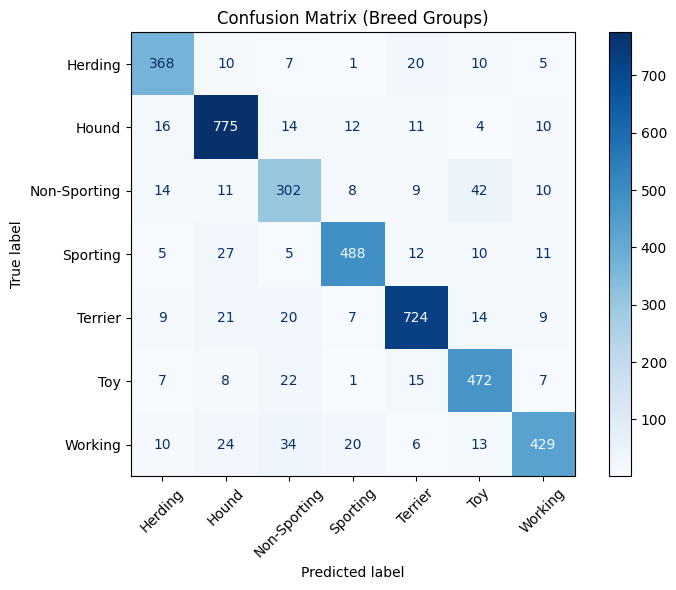

In [63]:
plot_group_confusion_matrices(model, test_loader, group_to_idx, device="cpu")

In [64]:
def breed_classification_report(model, dataloader, device, breed_to_idx):
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for images, _, breed_labels in dataloader:
            images, breed_labels = images.to(device), breed_labels.to(device)
            _, breed_logits = model(images)
            _, preds = torch.max(breed_logits, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(breed_labels.cpu().numpy())

    idx_to_breed = {v: k for k, v in breed_to_idx.items()}
    target_names = [idx_to_breed[i] for i in sorted(idx_to_breed.keys())]

    report = classification_report(all_labels, all_preds, target_names=target_names, zero_division=0)
    print("Classification Report by Breed:")
    print(report)

In [65]:
def group_classification_report(model, dataloader, device, group_to_idx):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, group_labels, _ in dataloader:
            images, group_labels = images.to(device), group_labels.to(device)
            group_logits, _ = model(images)
            _, preds = torch.max(group_logits, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(group_labels.cpu().numpy())

    idx_to_group = {v: k for k, v in group_to_idx.items()}
    target_names = [idx_to_group[i] for i in sorted(idx_to_group.keys())]

    report = classification_report(all_labels, all_preds, target_names=target_names, zero_division=0)
    print("Classification Report by Group:")
    print(report)

In [66]:
breed_classification_report(model, test_loader, device="cpu", breed_to_idx=breed_to_idx)
group_classification_report(model, test_loader, device="cpu", group_to_idx=group_to_idx)

Classification Report by Breed:
                                precision    recall  f1-score   support

                  Afghan_hound       0.88      0.86      0.87        49
           African_hunting_dog       0.89      0.89      0.89        36
                      Airedale       0.82      0.74      0.78        42
American_Staffordshire_terrier       0.86      0.56      0.68        34
                   Appenzeller       0.69      0.30      0.42        30
            Australian_terrier       0.65      0.73      0.69        41
            Bedlington_terrier       0.84      0.77      0.81        35
          Bernese_mountain_dog       0.83      0.83      0.83        42
              Blenheim_spaniel       0.90      0.90      0.90        40
                 Border_collie       0.62      0.86      0.72        29
                Border_terrier       0.79      0.89      0.84        35
                   Boston_bull       0.57      0.86      0.68        35
          Bouvier_des_Flandres 